# ML Model Training - Bi-LSTM Support Ticket Priority
This notebook trains and tunes the text-only Bi-LSTM model. It imports the single source of truth architecture from `src.models.train_classifier`.

In [1]:
#!pip install tensorflow pandas scikit-learn matplotlib seaborn keras-tuner

In [2]:
import sys
import os

# Add the project root directory to the python path
sys.path.append(os.path.abspath('..'))

from src.config import PROCESSED_DATA_DIR, MODELS_DIR
from src.models.train_classifier import set_global_seed

# Set random seeds for reproducibility
set_global_seed(42)

print(f"Data directory: {PROCESSED_DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Data directory: /Users/juanjose/Library/CloudStorage/GoogleDrive-rinconbrijj@gmail.com/My Drive/Support-Ticket-Priority-Classifier/data/processed
Models directory: /Users/juanjose/Library/CloudStorage/GoogleDrive-rinconbrijj@gmail.com/My Drive/Support-Ticket-Priority-Classifier/models


## Option 1: Run Full Pipeline Using Helper Functions
This cell runs the entire tuning, cross-validation, and final training using the modular functions from `tune_classifier.py`.

In [3]:
from src.models.tune_classifier import combine_for_cv, tune_hyperparameters, run_cross_validation, train_final_model_and_evaluate
from src.models.train_classifier import load_data, VOCAB_SIZE

# 1. Load Data
X_train_text, X_val_text, X_test_text, y_train, y_val, y_test, vocab = load_data()
actual_vocab_size = min(VOCAB_SIZE, len(vocab))

Loading data from /Users/juanjose/Library/CloudStorage/GoogleDrive-rinconbrijj@gmail.com/My Drive/Support-Ticket-Priority-Classifier/data/processed
Loaded X_train_text shape: (11436, 57)
Loaded y_train shape: (11436,)
Vocab size: 5726


In [4]:

# Combine train and val for tuning
X_cv_text, y_cv = combine_for_cv(X_train_text, X_val_text, y_train, y_val)


Combined CV Set (X_cv_text) shape: (13887, 57)
Combined CV Set (y_cv) shape: (13887,)


In [ ]:
from src.models.tune_classifier import combine_for_cv, tune_hyperparameters, run_cross_validation, train_final_model_and_evaluate
from src.models.train_classifier import load_data, VOCAB_SIZE

# 1. Load Data
X_train_text, X_val_text, X_test_text, y_train, y_val, y_test, vocab = load_data()
actual_vocab_size = min(VOCAB_SIZE, len(vocab))

# Combine train and val for tuning
X_cv_text, y_cv = combine_for_cv(X_train_text, X_val_text, y_train, y_val)

# 2. Run Hyperparameter Tuning
tuner, best_hps = tune_hyperparameters(X_cv_text, y_cv, actual_vocab_size)

# 3. Validate with Stratified K-Fold
run_cross_validation(best_hps, X_cv_text, y_cv, actual_vocab_size, n_splits=5)

# 4. Train final model and evaluate
train_final_model_and_evaluate(best_hps, X_cv_text, y_cv, X_test_text, y_test, actual_vocab_size)

In [5]:
import keras_tuner as kt

# Create a manual HyperParameters object
best_hps = kt.HyperParameters()

# Define the exact parameters you want to test
best_hps.Fixed('embedding_dim', 64)
best_hps.Fixed('lstm_units', 128)
best_hps.Fixed('dropout_1', 0.3)
best_hps.Fixed('learning_rate', 1e-3)

# Now you can pass `best_hps` directly to the cross-validation or final training functions!


0.001


--- Training Final Model on Full CV Set ---
Computed Class Weights: {np.int64(0): np.float64(1.6140167364016735), np.int64(1): np.float64(0.8229333333333333), np.int64(2): np.float64(0.8581757508342603)}
Epoch 1/30


/Users/juanjose/Library/CloudStorage/GoogleDrive-rinconbrijj@gmail.com/My Drive/Support-Ticket-Priority-Classifier/venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/juanjose/Library/CloudStorage/GoogleDrive-rinconbrijj@gmail.com/My Drive/Support-Ticket-Priority-Classifier/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


217/217 ━━━━━━━━━━━━━━━━━━━━ 36s 153ms/step - accuracy: 0.3833 - loss: 1.0607 - learning_rate: 0.0010
Epoch 2/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 40s 184ms/step - accuracy: 0.5114 - loss: 0.9496 - learning_rate: 0.0010
Epoch 3/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 39s 182ms/step - accuracy: 0.6051 - loss: 0.8287 - learning_rate: 0.0010
Epoch 4/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 40s 184ms/step - accuracy: 0.6689 - loss: 0.7146 - learning_rate: 0.0010
Epoch 5/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 40s 186ms/step - accuracy: 0.7192 - loss: 0.6275 - learning_rate: 0.0010
Epoch 6/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 40s 185ms/step - accuracy: 0.7575 - loss: 0.5444 - learning_rate: 0.0010
Epoch 7/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 44s 202ms/step - accuracy: 0.7864 - loss: 0.4835 - learning_rate: 0.0010
Epoch 8/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 45s 206ms/step - accuracy: 0.8121 - loss: 0.4388 - learning_rate: 0.0010
Epoch 9/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 45s 207ms/step - accuracy: 0.8319 - loss: 0.3902 - learning_rate: 0

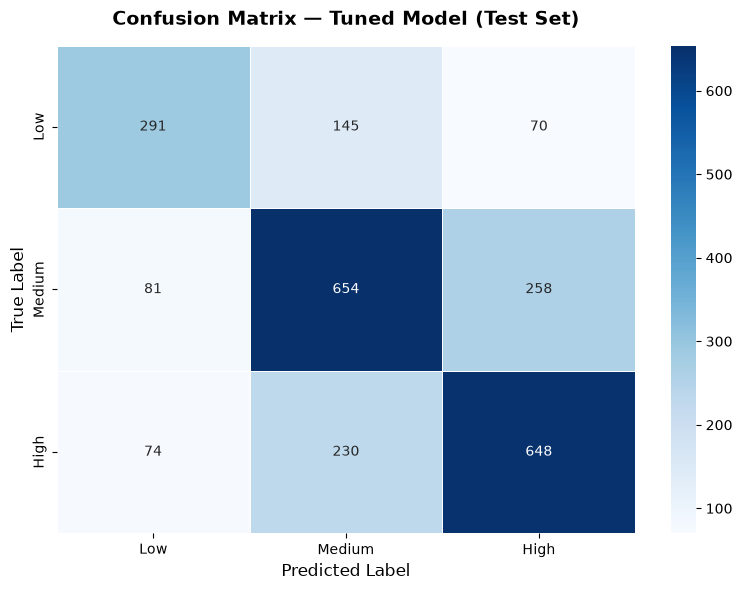

In [6]:
# 4. Train final model and evaluate
train_final_model_and_evaluate(best_hps, X_cv_text, y_cv, X_test_text, y_test, actual_vocab_size)

## Option 2: Run Hyperparameter Tuning with Explicit Functions
If you prefer to see and modify the tuning logic directly in the notebook, you can run this block instead. It still imports the single source of truth `build_model`.

In [ ]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
from src.models.train_classifier import load_data, build_model, get_class_weights, VOCAB_SIZE

# Load data
X_train_text, X_val_text, X_test_text, y_train, y_val, y_test, vocab = load_data()
actual_vocab_size = min(VOCAB_SIZE, len(vocab))

# Combine train/val for tuning
import numpy as np
X_cv_text = np.concatenate([X_train_text, X_val_text], axis=0)
y_train_int = np.argmax(y_train, axis=1) if len(y_train.shape) > 1 and y_train.shape[1] > 1 else y_train
y_val_int = np.argmax(y_val, axis=1) if len(y_val.shape) > 1 and y_val.shape[1] > 1 else y_val
y_cv = np.concatenate([y_train_int, y_val_int], axis=0)

def build_model_tuner(hp, actual_vocab_size):
    hp_embedding_dim = hp.Choice('embedding_dim', values=[32, 64, 128])
    hp_lstm_units = hp.Choice('lstm_units', values=[64, 128, 256])
    hp_dropout = hp.Float('dropout_1', min_value=0.2, max_value=0.6, step=0.1)
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    return build_model(
        actual_vocab_size=actual_vocab_size,
        embedding_dim=hp_embedding_dim,
        lstm_units=hp_lstm_units,
        dropout_rate=hp_dropout,
        learning_rate=hp_learning_rate
    )

tuner = kt.RandomSearch(
    hypermodel=lambda hp: build_model_tuner(hp, actual_vocab_size),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='../tuning_logs',
    project_name='ticket_classifier_tuning_notebook',
    overwrite=False,
    seed=42
)

class_weights = get_class_weights(y_cv)

print("\nStarting hyperparameter search...")
tuner.search(
    X_cv_text, y_cv, epochs=15, validation_split=0.2,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    batch_size=64, verbose=1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Optimal config: Embedding {best_hps.get('embedding_dim')}, LSTM {best_hps.get('lstm_units')}, LR {best_hps.get('learning_rate')}")